# Feature Engineering - Advanced Transformations

This notebook uses the same feature engineering helpers (inlined in the first code cell) and adds advanced transforms:
- Interaction features
- Polynomial features
- Feature selection and importance
- Dimensionality reduction (PCA)
- Feature statistics and distributions


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import joblib
from IPython.display import Markdown, display

# --- Inlined from former src/ (data_preparation + feature_engineering) ---

"""Data loading and basic cleaning pipeline for SaaS sales conversations.

This module prepares the dataset for exploratory data analysis (EDA) only.
No feature engineering or modeling is performed here.
"""

from typing import Optional, Union

import pandas as pd
from datasets import Dataset, DatasetDict, load_dataset


DATASET_NAME = "DeepMostInnovations/saas-sales-conversations"


def load_hf_dataset(dataset_name: str, split: Optional[str] = None) -> Union[Dataset, DatasetDict]:
    """Load a dataset from Hugging Face.

    Args:
        dataset_name: The Hugging Face dataset identifier.
        split: Optional split name (for example: "train"). If omitted,
            the full DatasetDict is loaded.

    Returns:
        A Dataset or DatasetDict depending on the provided split.
    """
    if split:
        return load_dataset(dataset_name, split=split)
    return load_dataset(dataset_name)


def dataset_to_dataframe(data: Union[Dataset, DatasetDict]) -> pd.DataFrame:
    """Convert Hugging Face Dataset/DatasetDict into a pandas DataFrame.

    If multiple splits are present, they are concatenated and a `split` column
    is added to preserve provenance.
    """
    if isinstance(data, Dataset):
        return data.to_pandas()

    if isinstance(data, DatasetDict):
        frames = []
        for split_name, split_ds in data.items():
            split_df = split_ds.to_pandas()
            split_df["split"] = split_name
            frames.append(split_df)

        return pd.concat(frames, ignore_index=True)

    raise TypeError("Input must be a Hugging Face Dataset or DatasetDict.")


def display_basic_info(df: pd.DataFrame) -> None:
    """Print dataset shape, column names, and dtypes."""
    print("\n=== BASIC DATASET INFO ===")
    print(f"Shape: {df.shape}")
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)


def check_missing_and_duplicates(df: pd.DataFrame) -> None:
    """Print missing-value counts and duplicate-row counts."""
    print("\n=== DATA QUALITY CHECKS ===")

    missing_counts = df.isna().sum().sort_values(ascending=False)
    print("\nMissing values per column:")
    print(missing_counts)

    duplicate_count = df.duplicated().sum()
    print(f"\nDuplicate rows: {duplicate_count}")


def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Perform basic cleaning for EDA readiness.

    Cleaning strategy:
    1. Drop fully empty rows.
    2. Remove duplicate rows.
    3. Fill missing values:
       - Numeric columns -> median
       - Non-numeric columns -> "Unknown"
    """
    cleaned_df = df.copy()

    # Remove rows that are entirely empty.
    cleaned_df = cleaned_df.dropna(how="all")

    # Keep first occurrence of each duplicated row.
    cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

    # Fill missing values by data type to make data EDA-friendly.
    numeric_cols = cleaned_df.select_dtypes(include=["number"]).columns
    categorical_cols = cleaned_df.select_dtypes(exclude=["number"]).columns

    if len(numeric_cols) > 0:
        cleaned_df[numeric_cols] = cleaned_df[numeric_cols].apply(
            lambda col: col.fillna(col.median())
        )

    if len(categorical_cols) > 0:
        cleaned_df[categorical_cols] = cleaned_df[categorical_cols].fillna("Unknown")

    return cleaned_df


def run_data_preparation(dataset_name: str = DATASET_NAME, split: Optional[str] = None) -> pd.DataFrame:
    """Run full data preparation flow and return cleaned DataFrame."""
    hf_data = load_hf_dataset(dataset_name=dataset_name, split=split)
    raw_df = dataset_to_dataframe(hf_data)

    display_basic_info(raw_df)
    check_missing_and_duplicates(raw_df)

    cleaned_df = clean_dataframe(raw_df)

    print("\n=== AFTER CLEANING ===")
    print(f"Shape: {cleaned_df.shape}")
    print(f"Duplicate rows: {cleaned_df.duplicated().sum()}")
    print("Missing values (sum across all columns):", int(cleaned_df.isna().sum().sum()))

    return cleaned_df

"""Reusable feature engineering pipeline for sales prediction.

This module converts a cleaned DataFrame into:
- Feature matrix X (scipy sparse matrix)
- Target vector y (pandas Series)

It supports two text strategies:
1) TF-IDF vectorization
2) Precomputed embeddings when available
"""

from dataclasses import dataclass
from typing import List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


@dataclass
class FeatureEngineeringConfig:
    """Configuration for building the feature matrix."""

    target_col: str = "outcome"
    text_col: str = "conversation_text"

    # Base numerical columns expected from the cleaned dataset.
    engagement_col: str = "customer_engagement"
    effectiveness_col: str = "sales_effectiveness"
    length_col: str = "conversation_length"

    # Text strategy options: "auto", "tfidf", "embeddings".
    text_strategy: str = "auto"
    embedding_prefix: str = "embedding_"

    # TF-IDF settings.
    tfidf_max_features: int = 3000
    tfidf_ngram_range: Tuple[int, int] = (1, 2)
    tfidf_min_df: int = 3

    # Keep one-hot encoding practical by skipping very high-cardinality columns.
    max_categorical_levels: int = 50
    max_categorical_ratio: float = 0.10


class SalesFeatureEngineer:
    """Builds engineered features and transforms them into a model-ready matrix."""

    def __init__(self, config: Optional[FeatureEngineeringConfig] = None) -> None:
        self.config = config or FeatureEngineeringConfig()

        self.numeric_cols_: List[str] = []
        self.categorical_cols_: List[str] = []
        self.embedding_cols_: List[str] = []
        self.text_mode_: str = ""

        self.scaler_: Optional[StandardScaler] = None
        self.encoder_: Optional[OneHotEncoder] = None
        self.tfidf_: Optional[TfidfVectorizer] = None

        self.feature_names_: List[str] = []
        self._fitted: bool = False

    def fit_transform(self, df: pd.DataFrame) -> Tuple[csr_matrix, pd.Series]:
        """Fit the feature pipeline and return transformed X, y."""
        prepared_df, y, text_series = self._prepare_base_dataframe(df)

        self._set_column_groups(prepared_df)
        self._set_text_mode(prepared_df)

        X_numeric = self._fit_transform_numeric(prepared_df)
        X_categorical = self._fit_transform_categorical(prepared_df)
        X_text = self._fit_transform_text(prepared_df, text_series)

        X = hstack([X_numeric, X_categorical, X_text], format="csr")
        self._build_feature_names()

        self._fitted = True
        return X, y

    def transform(self, df: pd.DataFrame) -> Tuple[csr_matrix, pd.Series]:
        """Transform new data with already-fitted transformers."""
        if not self._fitted:
            raise RuntimeError("Call fit_transform before transform.")

        prepared_df, y, text_series = self._prepare_base_dataframe(df)

        X_numeric = self._transform_numeric(prepared_df)
        X_categorical = self._transform_categorical(prepared_df)
        X_text = self._transform_text(prepared_df, text_series)

        X = hstack([X_numeric, X_categorical, X_text], format="csr")
        return X, y

    def get_feature_names(self) -> List[str]:
        """Return ordered feature names for matrix columns."""
        if not self._fitted:
            raise RuntimeError("Feature names are available only after fit_transform.")
        return self.feature_names_

    def get_text_mode(self) -> str:
        """Return effective text feature mode used by the pipeline."""
        if not self._fitted:
            raise RuntimeError("Text mode is available only after fit_transform.")
        return self.text_mode_

    def _prepare_base_dataframe(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
        """Prepare base columns and engineered features before encoding/vectorization."""
        if self.config.target_col not in df.columns:
            raise ValueError(f"Target column '{self.config.target_col}' is missing.")

        # Resolve text column robustly if preferred name is unavailable.
        text_col = self.config.text_col if self.config.text_col in df.columns else self._infer_text_column(df)
        if not text_col:
            raise ValueError("No suitable text column found for text feature engineering.")

        # Shallow copy avoids expensive block consolidation on very wide tables.
        working_df = df.copy(deep=False)

        # Create conversation length if missing.
        if self.config.length_col not in working_df.columns:
            working_df[self.config.length_col] = (
                working_df[text_col].fillna("").astype(str).str.split().str.len()
            )

        required_numeric = [
            self.config.engagement_col,
            self.config.effectiveness_col,
            self.config.length_col,
        ]
        missing_numeric = [col for col in required_numeric if col not in working_df.columns]
        if missing_numeric:
            raise ValueError(f"Missing numeric columns required for engineering: {missing_numeric}")

        numeric_converted = {
            col: pd.to_numeric(working_df[col], errors="coerce")
            for col in required_numeric + [self.config.target_col]
        }
        for col, series in numeric_converted.items():
            working_df[col] = series

        # Keep rows where target and core numeric columns are valid.
        working_df = working_df.dropna(subset=required_numeric + [self.config.target_col]).copy()
        working_df[self.config.target_col] = working_df[self.config.target_col].astype(int)

        # Core engineered numeric features.
        eps = 1e-6
        working_df["engagement_per_length"] = (
            working_df[self.config.engagement_col] / (working_df[self.config.length_col] + eps)
        )
        working_df["effectiveness_per_length"] = (
            working_df[self.config.effectiveness_col] / (working_df[self.config.length_col] + eps)
        )
        working_df["engagement_x_effectiveness"] = (
            working_df[self.config.engagement_col] * working_df[self.config.effectiveness_col]
        )

        # Optional categorical columns (excluding text and target).
        excluded = {
            text_col,
            self.config.target_col,
        }
        candidate_cats = [
            col
            for col in working_df.select_dtypes(include=["object", "category", "string"]).columns
            if col not in excluded
        ]

        # Encode only low/moderate-cardinality columns to avoid giant sparse matrices.
        cat_cols: List[str] = []
        for col in candidate_cats:
            nunique = int(working_df[col].nunique(dropna=True))
            ratio = nunique / max(len(working_df), 1)
            if nunique <= self.config.max_categorical_levels and ratio <= self.config.max_categorical_ratio:
                cat_cols.append(col)

        self.categorical_cols_ = cat_cols

        text_series = working_df[text_col].fillna("").astype(str)
        y = working_df[self.config.target_col]

        return working_df, y, text_series

    def _set_column_groups(self, prepared_df: pd.DataFrame) -> None:
        """Define numeric and embedding feature groups."""
        self.embedding_cols_ = [
            col for col in prepared_df.columns if col.startswith(self.config.embedding_prefix)
        ]

        base_numeric = [
            self.config.engagement_col,
            self.config.effectiveness_col,
            self.config.length_col,
            "engagement_per_length",
            "effectiveness_per_length",
            "engagement_x_effectiveness",
        ]
        self.numeric_cols_ = [col for col in base_numeric if col in prepared_df.columns]

    def _set_text_mode(self, prepared_df: pd.DataFrame) -> None:
        """Select effective text strategy based on config and data availability."""
        strategy = self.config.text_strategy.lower()
        if strategy not in {"auto", "tfidf", "embeddings"}:
            raise ValueError("text_strategy must be one of: auto, tfidf, embeddings")

        if strategy == "auto":
            self.text_mode_ = "embeddings" if self.embedding_cols_ else "tfidf"
        elif strategy == "embeddings":
            if not self.embedding_cols_:
                raise ValueError("Embeddings strategy requested, but no embedding columns were found.")
            self.text_mode_ = "embeddings"
        else:
            self.text_mode_ = "tfidf"

    def _fit_transform_numeric(self, prepared_df: pd.DataFrame) -> csr_matrix:
        self.scaler_ = StandardScaler()
        numeric_values = prepared_df[self.numeric_cols_].to_numpy(dtype=float)
        numeric_scaled = self.scaler_.fit_transform(numeric_values)
        return csr_matrix(numeric_scaled)

    def _transform_numeric(self, prepared_df: pd.DataFrame) -> csr_matrix:
        if self.scaler_ is None:
            raise RuntimeError("Numeric scaler is not fitted.")
        numeric_values = prepared_df[self.numeric_cols_].to_numpy(dtype=float)
        numeric_scaled = self.scaler_.transform(numeric_values)
        return csr_matrix(numeric_scaled)

    def _fit_transform_categorical(self, prepared_df: pd.DataFrame) -> csr_matrix:
        if not self.categorical_cols_:
            self.encoder_ = None
            return csr_matrix((len(prepared_df), 0))

        self.encoder_ = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
        return self.encoder_.fit_transform(prepared_df[self.categorical_cols_])

    def _transform_categorical(self, prepared_df: pd.DataFrame) -> csr_matrix:
        if not self.categorical_cols_:
            return csr_matrix((len(prepared_df), 0))
        if self.encoder_ is None:
            raise RuntimeError("Categorical encoder is not fitted.")
        return self.encoder_.transform(prepared_df[self.categorical_cols_])

    def _fit_transform_text(self, prepared_df: pd.DataFrame, text_series: pd.Series) -> csr_matrix:
        if self.text_mode_ == "embeddings":
            return csr_matrix(prepared_df[self.embedding_cols_].to_numpy(dtype=float))

        self.tfidf_ = TfidfVectorizer(
            max_features=self.config.tfidf_max_features,
            ngram_range=self.config.tfidf_ngram_range,
            min_df=self.config.tfidf_min_df,
            lowercase=True,
            strip_accents="unicode",
        )
        return self.tfidf_.fit_transform(text_series)

    def _transform_text(self, prepared_df: pd.DataFrame, text_series: pd.Series) -> csr_matrix:
        if self.text_mode_ == "embeddings":
            return csr_matrix(prepared_df[self.embedding_cols_].to_numpy(dtype=float))

        if self.tfidf_ is None:
            raise RuntimeError("TF-IDF vectorizer is not fitted.")
        return self.tfidf_.transform(text_series)

    def _build_feature_names(self) -> None:
        """Compose ordered feature names for all matrix blocks."""
        feature_names: List[str] = []

        feature_names.extend(self.numeric_cols_)

        if self.encoder_ is not None and self.categorical_cols_:
            feature_names.extend(self.encoder_.get_feature_names_out(self.categorical_cols_).tolist())

        if self.text_mode_ == "embeddings":
            feature_names.extend(self.embedding_cols_)
        else:
            if self.tfidf_ is None:
                raise RuntimeError("TF-IDF vectorizer missing during feature name generation.")
            feature_names.extend([f"tfidf__{t}" for t in self.tfidf_.get_feature_names_out()])

        self.feature_names_ = feature_names

    @staticmethod
    def _infer_text_column(df: pd.DataFrame) -> str:
        """Infer a natural language text column while avoiding ID-like columns."""
        object_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
        if not object_cols:
            return ""

        preferred_tokens = ["conversation_text", "transcript", "utterance", "message", "chat", "text"]

        scored: List[Tuple[str, float]] = []
        for col in object_cols:
            col_l = col.lower()
            id_penalty = -5 if any(tok in col_l for tok in ["_id", "id", "uuid", "key"]) else 0
            name_bonus = sum(tok in col_l for tok in preferred_tokens)

            sample = df[col].dropna().astype(str).head(1000)
            if sample.empty:
                content_bonus = -1.0
            else:
                has_space_ratio = sample.str.contains(r"\s", regex=True).mean()
                avg_words = sample.str.split().str.len().mean()
                content_bonus = (2.0 if has_space_ratio >= 0.4 else 0.0) + (2.0 if avg_words >= 4 else 0.0)

            total_score = float(name_bonus + id_penalty + content_bonus)
            scored.append((col, total_score))

        scored.sort(key=lambda x: x[1], reverse=True)
        best_col, best_score = scored[0]
        return best_col if best_score >= 2 else ""


def get_feature_rationale_markdown(text_mode: str) -> str:
    """Human-readable explanation of why each feature block is created."""
    text_choice = "precomputed embeddings" if text_mode == "embeddings" else "TF-IDF"

    return (
        "### Why These Features Are Created\n"
        "- **engagement_per_length**: Captures engagement density, not just raw engagement.\n"
        "- **effectiveness_per_length**: Measures sales effectiveness normalized by conversation size.\n"
        "- **engagement_x_effectiveness**: Models interaction where strong engagement and effectiveness together can amplify conversion probability.\n"
        "- **Categorical one-hot features**: Preserve segment-level information (for example, channel or region) without imposing fake ordinal relationships.\n"
        f"- **Text features ({text_choice})**: Convert conversation language into machine-usable signals for intent, objections, urgency, and buying cues.\n"
        "- **Standard scaling on numeric block**: Brings numeric features to comparable scale for stable optimization and fair regularization impact."
    )

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)


/Users/bhavanishanker/predictive-sales-analytics-engine/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Prepare Data

In [ ]:
# Load data
try:
    if cleaned_df is not None:
        print(f'Using pre-loaded data: {cleaned_df.shape}')
except NameError:
    print('Loading data from HuggingFace...')
    raw_data = load_hf_dataset('DeepMostInnovations/saas-sales-conversations')
    cleaned_df = dataset_to_dataframe(raw_data)
    print(f'Data loaded: {cleaned_df.shape}')

# Split target
y = cleaned_df['outcome'].astype(int)
# Drop outcome and outcome_label (if it exists), using errors='ignore' to handle missing columns
X_raw = cleaned_df.drop(['outcome', 'outcome_label'], axis=1, errors='ignore')
feature_cols_raw = X_raw.columns.tolist()

print(f'Features: {len(feature_cols_raw)}')
print(f'Target distribution: {y.value_counts().to_dict()}')

Loading data from HuggingFace...


Data loaded: (100000, 3089)
Features: 3088
Target distribution: {0: 50071, 1: 49929}


## 2. Transform to Feature Matrix

In [3]:
# Feature matrix via SalesFeatureEngineer
fe_config = FeatureEngineeringConfig(text_strategy='embeddings')
feature_engineer = SalesFeatureEngineer(fe_config)
X_engineered, _ = feature_engineer.fit_transform(cleaned_df)

feature_names = feature_engineer.get_feature_names()
print(f'Engineered feature matrix shape: {X_engineered.shape}')
print(f'Feature matrix type: {type(X_engineered)}')
print(f'Memory usage (approx): {X_engineered.data.nbytes / 1e9:.2f} GB')

Engineered feature matrix shape: (100000, 3187)
Feature matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Memory usage (approx): 2.47 GB


## 3. Feature Selection (Statistical Tests)

In [4]:
# Select top K features using f-statistic
n_features_selected = min(500, X_engineered.shape[1])

selector = SelectKBest(f_classif, k=n_features_selected)
X_selected = selector.fit_transform(X_engineered, y)

# Get selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_indices]

print(f'Selected {n_features_selected} features (from {X_engineered.shape[1]})')
print(f'Top 10 selected features:')
for i, idx in enumerate(selected_indices[:10]):
    score = selector.scores_[idx]
    print(f'  {i+1}. {feature_names[idx]}: score={score:.2f}')

/Users/bhavanishanker/predictive-sales-analytics-engine/.venv/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/bhavanishanker/predictive-sales-analytics-engine/.venv/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Selected 500 features (from 3187)
Top 10 selected features:
  1. customer_engagement: score=159097.72
  2. sales_effectiveness: score=273788.87
  3. engagement_per_length: score=69749.37
  4. effectiveness_per_length: score=145160.57
  5. engagement_x_effectiveness: score=351849.06
  6. embedding_0: score=702.51
  7. embedding_5: score=719.74
  8. embedding_9: score=741.64
  9. embedding_13: score=1384.05
  10. embedding_24: score=675.55


## 4. Dimensionality Reduction with PCA

PCA applied: (100000, 100)
Explained variance (first 10 components): [0.84529916 0.92782485 0.98866051 0.9897877  0.99044662 0.9910053
 0.99154844 0.99200222 0.9924203  0.99278643]
Components needed for 90% variance: 2


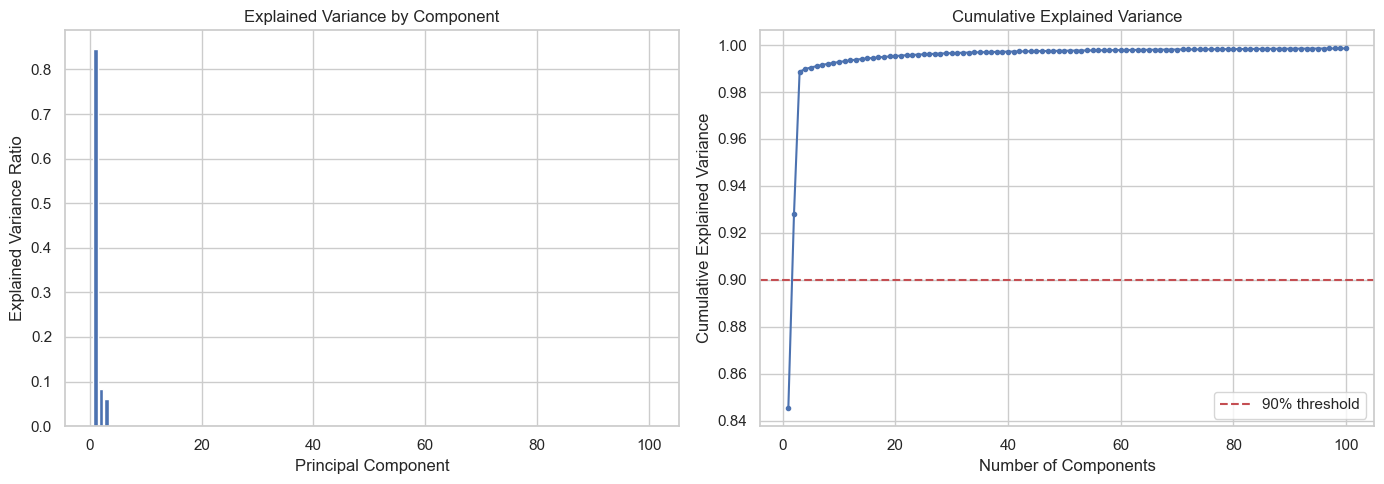

✓ Saved to figures/feature_engineering_pca_variance.png


In [5]:
# Apply PCA to selected features
n_components = min(100, X_selected.shape[1])
pca = PCA(n_components=n_components, random_state=42)

# PCA requires dense matrix for large sparse inputs, so use selected features
X_selected_dense = X_selected.toarray() if sparse.issparse(X_selected) else X_selected
X_pca = pca.fit_transform(X_selected_dense)

explained_variance = pca.explained_variance_ratio_.cumsum()
n_components_90 = np.argmax(explained_variance >= 0.9) + 1

print(f'PCA applied: {X_pca.shape}')
print(f'Explained variance (first 10 components): {explained_variance[:10]}')
print(f'Components needed for 90% variance: {n_components_90}')

# Plot explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(range(1, n_components+1), pca.explained_variance_ratio_[:n_components])
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Explained Variance by Component')

ax2.plot(range(1, n_components+1), explained_variance, marker='o', linestyle='-', markersize=3)
ax2.axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
plt.tight_layout()
plt.savefig('../figures/feature_engineering_pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved to figures/feature_engineering_pca_variance.png')

## 5. Feature Engineering Summary

In [6]:
summary_text = f"""
## Feature Engineering Summary

### Original Features
- Raw features: {X_raw.shape[1]}
- Engineered features: {X_engineered.shape[1]}

### Feature Selection
- Selected best {n_features_selected} features using f-statistic
- Reduction: {100 * n_features_selected / X_engineered.shape[1]:.1f}% of engineered features

### Dimensionality Reduction (PCA)
- Reduced to {n_components_90} components for 90% variance retention
- Final matrix shape: {X_pca.shape}

### Feature Matrix Formats
1. **X_engineered**: Full sparse matrix ({X_engineered.shape})
2. **X_selected**: Selected dense features ({X_selected_dense.shape})
3. **X_pca**: PCA-reduced features ({X_pca.shape})

### Next Steps
- Use X_pca for fast model training with 90% variance retained
- Use X_selected for model interpretability
- Use X_engineered for maximum information (if computational resources allow)
"""

display(Markdown(summary_text))

# Save feature information
feature_info = {
    'n_original': X_raw.shape[1],
    'n_engineered': X_engineered.shape[1],
    'n_selected': n_features_selected,
    'n_pca': n_components,
    'pca_variance_90': float(n_components_90),
    'selected_features': selected_features[:50]  # Top 50
}

import json
with open('../metrics/feature_engineering_summary.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print('✓ Saved feature info to metrics/feature_engineering_summary.json')


## Feature Engineering Summary

### Original Features
- Raw features: 3088
- Engineered features: 3187

### Feature Selection
- Selected best 500 features using f-statistic
- Reduction: 15.7% of engineered features

### Dimensionality Reduction (PCA)
- Reduced to 2 components for 90% variance retention
- Final matrix shape: (100000, 100)

### Feature Matrix Formats
1. **X_engineered**: Full sparse matrix ((100000, 3187))
2. **X_selected**: Selected dense features ((100000, 500))
3. **X_pca**: PCA-reduced features ((100000, 100))

### Next Steps
- Use X_pca for fast model training with 90% variance retained
- Use X_selected for model interpretability
- Use X_engineered for maximum information (if computational resources allow)


✓ Saved feature info to metrics/feature_engineering_summary.json


## 6. Save Engineered Datasets

In [7]:
# Save datasets for use in model training notebook
import scipy.sparse as sp

# Save sparse matrices
sp.save_npz('../results/X_engineered.npz', X_engineered.tocsr())
np.save('../results/X_selected.npy', X_selected_dense)
np.save('../results/X_pca.npy', X_pca)
np.save('../results/y.npy', y.values)

# Save feature names and metadata
joblib.dump(feature_names, '../results/feature_names.pkl')
joblib.dump(selected_features, '../results/selected_features.pkl')
joblib.dump(pca, '../results/pca_model.pkl')
joblib.dump(selector, '../results/feature_selector.pkl')

print('✓ Saved engineered datasets:')
print('  - X_engineered.npz (sparse matrix)')
print('  - X_selected.npy')
print('  - X_pca.npy')
print('  - y.npy')
print('  - feature_names.pkl')
print('  - selected_features.pkl')
print('  - pca_model.pkl')
print('  - feature_selector.pkl')

✓ Saved engineered datasets:
  - X_engineered.npz (sparse matrix)
  - X_selected.npy
  - X_pca.npy
  - y.npy
  - feature_names.pkl
  - selected_features.pkl
  - pca_model.pkl
  - feature_selector.pkl
